### Import Libraries and Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
car_insurance_fraud_df = pd.read_csv(r'car_insurance_fraud_dataset.csv')
car_insurance_fraud_df_copy = car_insurance_fraud_df.copy(deep=True)
car_insurance_fraud_df_copy.shape

(30000, 24)

In [3]:
pd.set_option('display.max_columns', 24)
car_insurance_fraud_df_copy.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [4]:
car_insurance_fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [5]:
car_insurance_fraud_df.describe().T

,count,mean,std,min,25%,50%,75%,max
policy_deductible,30000.0,562.783333,250.413012,200.00,300.0000,600.000,800.0000,1000.00
policy_annual_premium,30000.0,1051.255214,260.357163,600.02,826.3200,1051.155,1277.9025,1499.98
insured_age,30000.0,46.500133,16.707778,18.00,32.0000,46.000,61.0000,75.00
incident_hour_of_the_day,30000.0,11.505000,6.896155,0.00,6.0000,12.000,17.0000,23.00
number_of_vehicles_involved,30000.0,2.508933,1.116555,1.00,2.0000,3.000,4.0000,4.00
bodily_injuries,30000.0,1.997600,1.411829,0.00,1.0000,2.000,3.0000,4.00
witnesses,30000.0,2.504667,1.707691,0.00,1.0000,2.000,4.0000,5.00
claim_amount,30000.0,10823.078981,6629.690781,266.74,5350.9475,10204.170,15381.8675,29719.87
total_claim_amount,30000.0,12757.736600,7028.920069,502.18,6685.5075,12740.430,18809.9100,24999.72


In [ ]:
car_insurance_fraud_df_copy.drop(columns=['policy_id', ''], inplace=True)
car_insurance_fraud_df_copy.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [7]:
categorical_columns = car_insurance_fraud_df_copy.select_dtypes(include='object')
numerical_columns = car_insurance_fraud_df_copy.select_dtypes(include='number')

In [8]:
categorical_columns.head()

,policy_state,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,police_report_available,fraud_reported
0,GA,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,Charlesville,Yes,Y
1,PA,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,No,N
2,MI,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,No,N
3,CA,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,Josephchester,No,N
4,MI,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,No,N


In [9]:
numerical_columns.head()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
0,400,1430.78,74,6,1,4,0,8161.36,11677.60
1,300,854.49,74,0,3,4,5,18561.79,18027.81
2,400,1247.28,28,14,4,4,1,10734.61,10375.59
3,600,622.42,37,22,3,3,5,13188.92,14204.34
4,700,1458.17,31,18,4,2,4,21864.69,24038.84


In [10]:
for col in categorical_columns:
    print(car_insurance_fraud_df[col].value_counts())
    print('_'*40)

policy_state
GA    3133
NY    3034
OH    3026
MI    3004
PA    2997
NC    2990
FL    2981
IL    2973
CA    2951
TX    2911
Name: count, dtype: int64
________________________________________
insured_sex
OTHER     10088
MALE      10037
FEMALE     9875
Name: count, dtype: int64
________________________________________
insured_education_level
High School    7554
PhD            7514
Masters        7477
College        7455
Name: count, dtype: int64
________________________________________
insured_occupation
Teacher       3799
Doctor        3778
Manager       3777
Clerk         3773
Technician    3758
Lawyer        3725
Sales         3702
Engineer      3688
Name: count, dtype: int64
________________________________________
insured_hobbies
paintball    4345
hiking       4328
yachting     4296
camping      4284
reading      4265
movies       4258
chess        4224
Name: count, dtype: int64
________________________________________
incident_date
2024-07-31    64
2025-06-23    62
2024-05-08    59


In [11]:
for col in numerical_columns:
    print(car_insurance_fraud_df[col].value_counts())
    print('_'*40)

policy_deductible
700     3794
1000    3781
200     3771
400     3768
300     3761
800     3757
500     3694
600     3674
Name: count, dtype: int64
________________________________________
policy_annual_premium
1177.08    5
1327.50    5
983.71     5
1423.54    5
1050.76    5
          ..
773.47     1
608.33     1
838.35     1
1262.28    1
1277.15    1
Name: count, Length: 25469, dtype: int64
________________________________________
insured_age
45    560
41    555
42    551
30    550
43    548
71    548
40    541
69    541
44    540
26    539
27    539
39    538
25    537
73    536
50    535
59    535
20    534
36    532
67    530
65    529
74    526
52    525
34    524
62    524
47    524
29    524
32    523
48    522
64    521
46    519
63    518
61    517
75    516
49    515
19    513
68    511
18    509
58    507
22    504
60    504
31    502
21    500
53    499
57    499
23    498
51    497
54    496
35    490
56    489
55    489
38    489
33    488
72    488
66    487
28    486
37

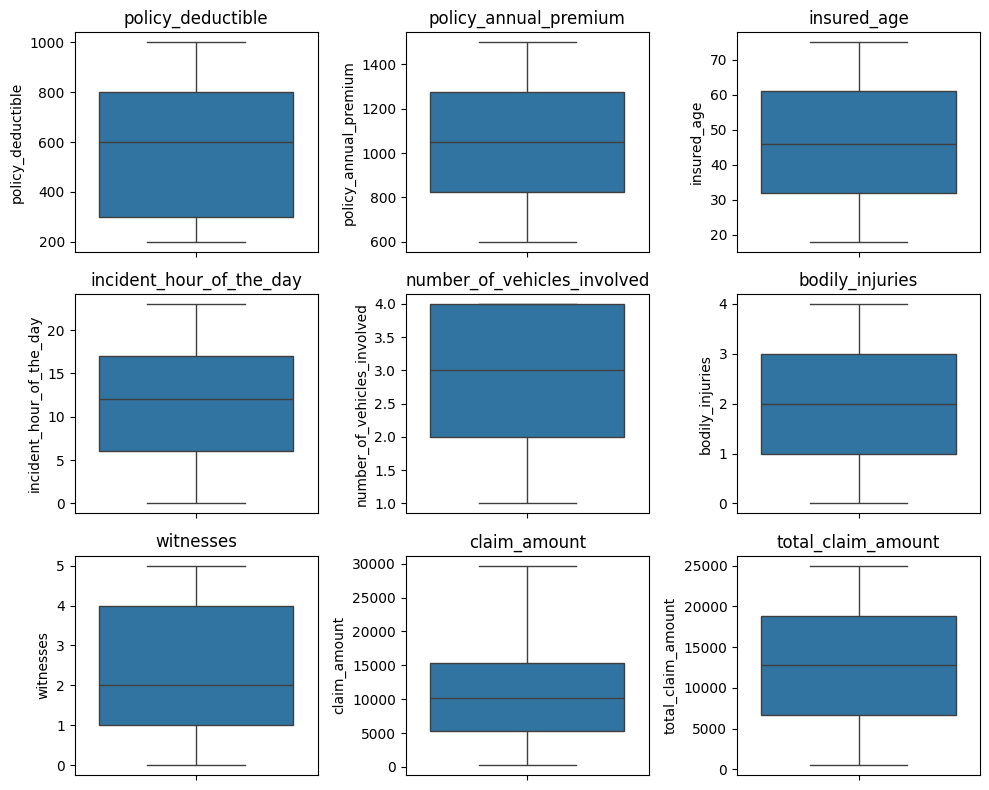

In [14]:
columns = numerical_columns

# Create subplot grid (2x2 here)
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

axes = axes.flatten()  # make it 1D for easy looping

# Loop through columns
for i, col in enumerate(columns):
    sns.boxplot(y=car_insurance_fraud_df_copy[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

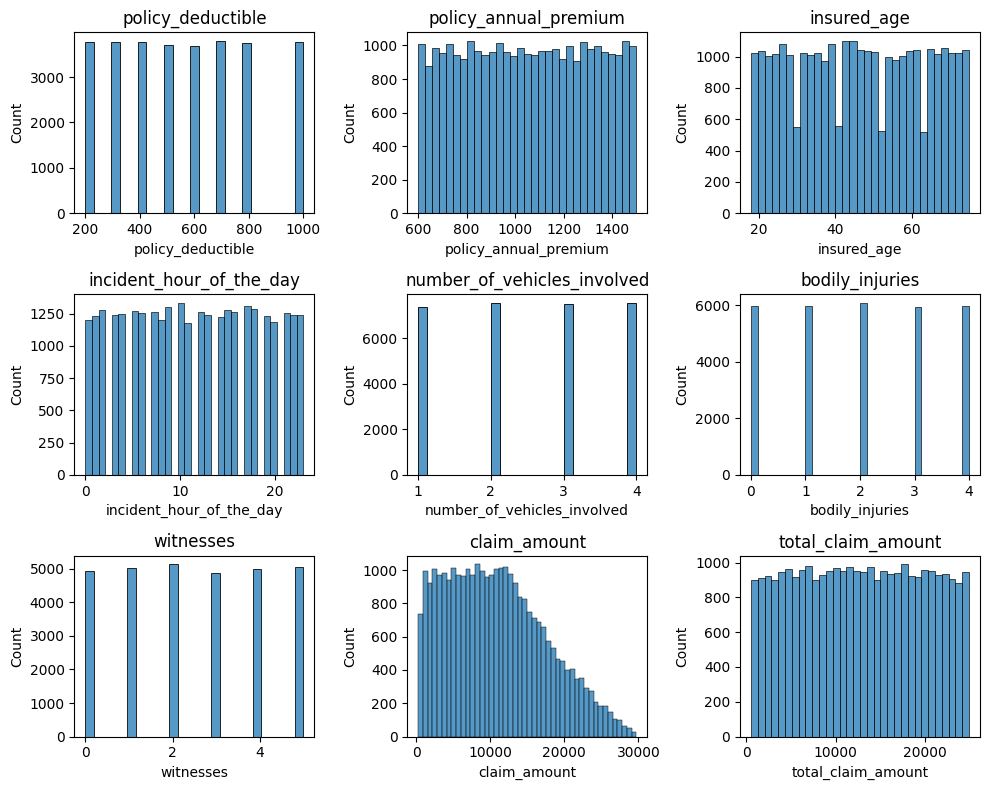

In [17]:
columns = numerical_columns

fig, axes = plt.subplots(3, 3, figsize=(10, 8))

axes = axes.flatten()  

# Loop through columns
for i, col in enumerate(numerical_columns):
    sns.histplot(data=car_insurance_fraud_df_copy, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

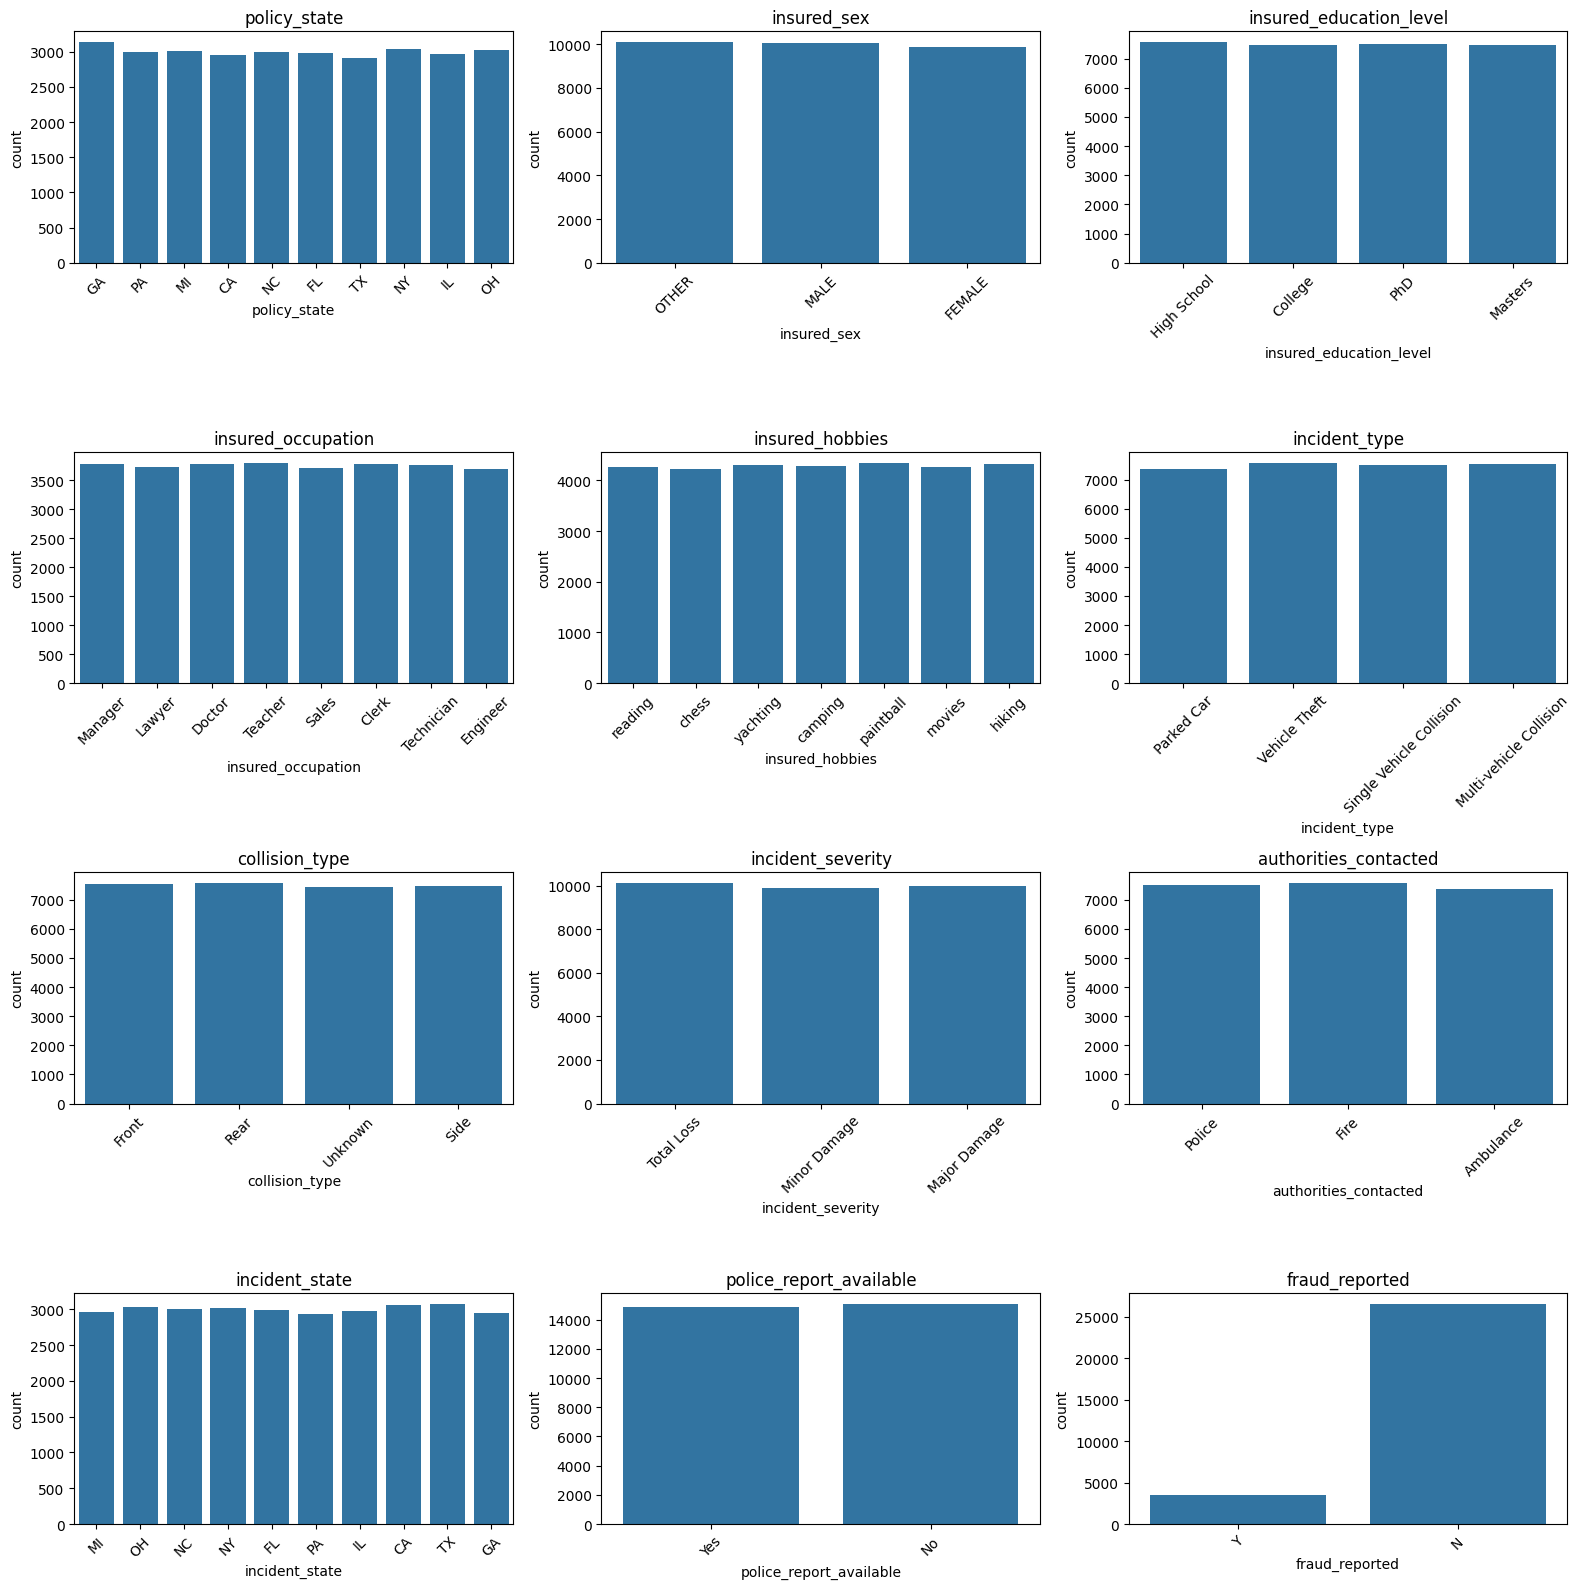

In [37]:
columns = categorical_columns

fig, axes = plt.subplots(4, 3, figsize=(16, 16))

axes = axes.flatten()  

for i, col in enumerate(categorical_columns.drop(['incident_city', 'incident_date'], axis=1)):
    sns.countplot(data=car_insurance_fraud_df_copy, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)  # optional (for readability)

plt.tight_layout()
plt.show()